In [1]:
import cafe

cafe.logger.setLevel("DEBUG")

INFO                                                                                                                                                                                                    
            _____     _ _ ______    _       ______            _                                                                                                                                         
           / ____|   | | |  ____|  | |     |  ____|          | |                                                                                                                                        
          | |     ___| | | |__ __ _| |_ ___| |__  __  ___ __ | | ___  _ __ ___ _ __                                                                                                                     
          | |    / _ \ | |  __/ _` | __/ _ \  __| \ \/ / '_ \| |/ _ \| '__/ _ \ '__|                                                                                                                

read trajectory result

DEBUG    |- Reading data from '/root/PyCode/scRNA/data/Pancreas/endocrinogenesis_day15.h5ad'...                                                                                                         
DEBUG    |- transfer 'X' and 'Spliced' matrix from csr to csc for better dynverse docker performance                                                                                                    
DEBUG    |- Create a FateAnnData object from an existing AnnData object.                                                                                                                                
DEBUG    |- recognizing prior information...                                                                                                                                                            
DEBUG    |--- recognize 'clusters' in '.obs' columns as 'cluster' key                                                                                                                               

<Axes: title={'center': 'dynamo-conda(clusters)'}, xlabel='X_umap1', ylabel='X_umap2'>

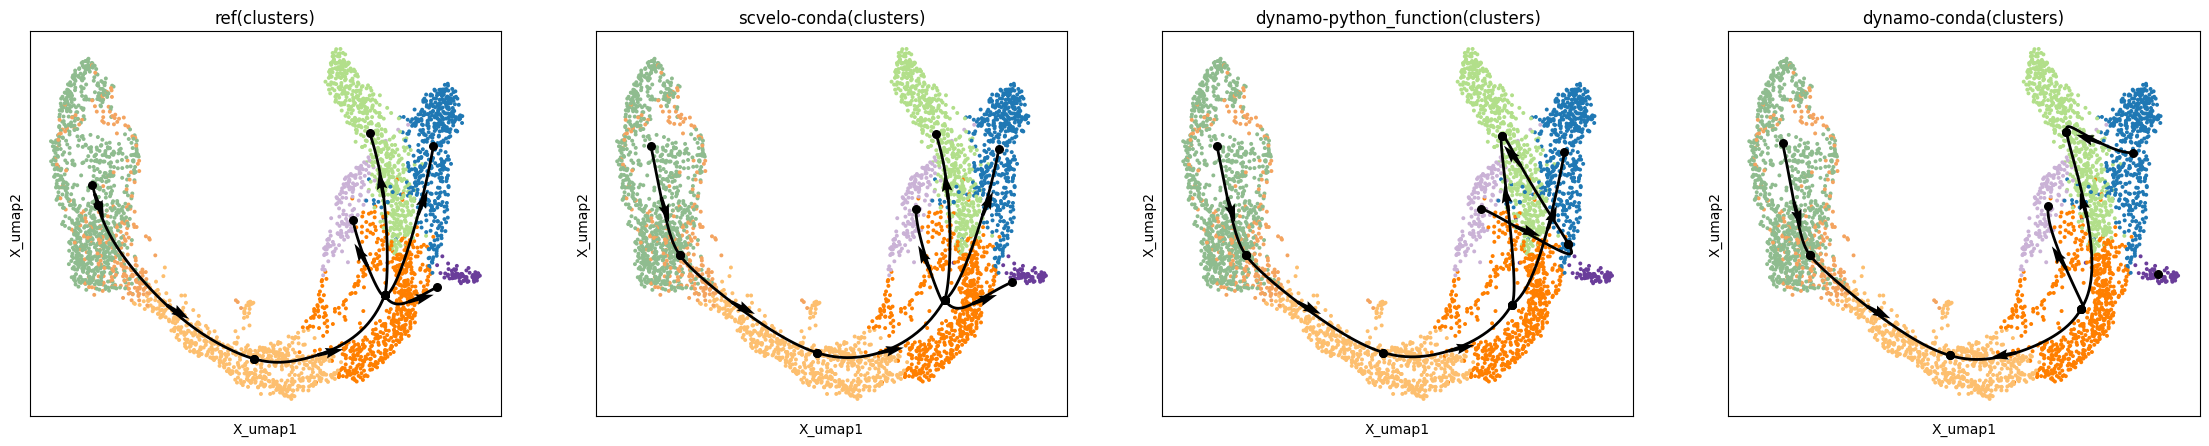

In [41]:
model_name_list = [
    "20251029_175941__scvelo-conda__DtOVOTp4mf", 
    "20251030_112820__dynamo-python_function__0wb9b9ul4C",
    "20251105_120424__dynamo-conda__FlFIzJwtMI"
    ]
fadata = cafe.data.read_pancrease()
del fadata.uns["neighbors"] # velocity neighbor info error, need recalculate

fadata.load_trajectory_dict(model_name_list=model_name_list) # load all trajectories

model_name_list = fadata.get_all_model_name(parse=False)
# color_list = ["clusters", "milestone"] # delete "milestone" to speed up
color_list = ["clusters"]

cafe.plot.plot_trajectory(fadata, model_name=model_name_list, color=color_list)

calculate metric

In [ ]:
import os
import pandas as pd

# metrics = [
#     "pseudotime_correlation",
#     "velocity_cbdir",
#     "velocity_icvcoh",
#     "isomorphic",
#     "edge_flip",
#     "him",
#     "correlation",
#     "F1_branches",
#     "F1_milestones",
# ]
metrics = None  # calculate all metrics


# cbdir
cluster_edges = {
    ("Ductal", "Ngn3 low EP"),
    ("Ngn3 low EP", "Ngn3 high EP"),
    ("Ngn3 high EP", "Pre-endocrine"),
    ("Pre-endocrine", "Alpha"),
    ("Pre-endocrine", "Beta"),
    ("Pre-endocrine", "Delta"),
    ("Pre-endocrine", "Epsilon"),
}


# load calculated metric csv file
metric_dir = f".cfe/{fadata.id}/metric/"
metric_file_list = os.listdir(metric_dir)

model_name_list = fadata.get_all_model_name(parse=False)
todo_model_name_list = []
calculated_metric_df_list = []
for model_name in model_name_list:
    metric_file = f"{model_name}.csv"
    if metric_file in metric_file_list:
        cafe.logger.info(f"metric file for model {model_name} already exists. read it.")
        calculated_metric_df = pd.read_csv(f"{metric_dir}/{metric_file}", index_col=0).T
        calculated_metric_df_list.append(calculated_metric_df)
    else:
        todo_model_name_list.append(model_name)
metric_df = pd.concat(calculated_metric_df_list)

# calculate new metric
todo_model_name_list.remove("ref")
if len(todo_model_name_list) > 0:
    cafe.logger.info(f"calculating metrics for models: {todo_model_name_list}")
    new_metric_df = cafe.metric.calculate_metrics(fadata, now_models=todo_model_name_list, metrics=metrics, cluster_edges=cluster_edges)
    new_metric_df.apply(lambda x: x.to_csv(f"{metric_dir}/{x.name}.csv"), axis=1)
    metric_df = pd.concat([metric_df, new_metric_df])

# save summary metric
metric_df.to_csv(f"{metric_dir}/summary.csv")

metric_df

INFO     |- Metric file for model 20251029_175941__scvelo-conda__DtOVOTp4mf already exists. read it Skipping recalculation.                                                                             
INFO     |- Metric file for model 20251030_112820__dynamo-python_function__0wb9b9ul4C already exists. read it Skipping recalculation.                                                                   
INFO     |- Calculating metrics for models: ['20251105_120424__dynamo-conda__FlFIzJwtMI']                                                                                                               
INFO     |- neighbors not found in fadata.uns, computing neighbors for velocity metric calculation.                                                                                                     
DEBUG    |- Create a FateAnnData object from an existing AnnData object.                                                                                                                            

,pseudotime_correlation,velocity_cbdir,velocity_icvcoh,isomorphic,edge_flip,him,correlation,F1_branches,F1_milestones,rf_mse,rf_nmse,rf_rsq,lm_nmse,lm_mse,lm_rsq,featureimp_cor,featureimp_wcor
20251029_175941__scvelo-conda__DtOVOTp4mf,0.990982,0.538780,0.787854,1.0,1.000000,0.961104,0.882257,1.000000,1.000000,5.590169e-07,0.999993,0.999989,1.000000,0.000000,1.000000,1.000000,1.000000
20251030_112820__dynamo-python_function__0wb9b9ul4C,0.766500,0.332580,0.599873,0.0,0.571429,0.384133,0.764831,0.746747,0.933246,1.121487e-03,0.985927,0.968935,0.971032,0.002309,0.931021,0.990252,0.977650
20251105_120424__dynamo-conda__FlFIzJwtMI,0.070649,0.528763,0.771394,0.0,0.500000,0.560073,0.778714,0.775247,0.940568,3.361288e-03,0.957821,0.953263,0.955348,0.003558,0.944326,0.989063,0.974423


: 

In [ ]:
metric_df.apply(lambda x: x.to_csv(f".cfe/{fadata.id}/metric/{x.name}.csv"), axis=1)
metric_df.to_csv(f".cfe/{fadata.id}/metric/summary.csv")

benchmark visualization

In [4]:
import numpy as np
import pandas as pd

if_normalize_metric = True
if if_normalize_metric:
    metric_meta_df = cafe.metric.metrics.set_index("metric_id")
    # normalize the metrics
    metric_df_normalized = pd.DataFrame()
    for metric_name in metric_df.columns:
        perfect = metric_meta_df.loc[metric_name, "perfect"]
        worst = metric_meta_df.loc[metric_name, "worst"]
        metric_normalized = metric_df[metric_name]
        if metric_df[metric_name].isna().any():
            impute_value = (worst+perfect)/2
            print(f"impute value: '{impute_value}' for NaN shown in metric '{metric_name}'")
            metric_normalized = metric_normalized.fillna(impute_value) # fillna with mid value
        metric_normalized = (metric_normalized-worst)/(perfect - worst)
        metric_df_normalized[metric_name] = metric_normalized
    benchmark_df = metric_df_normalized
else:
    benchmark_df = metric_df

# add benchmark info        
def add_benchmark_info(row):
    model_name = row.name
    row["id"] = cafe.util.parse_random_time_string(model_name).split('-')[0]
    # wrapper type
    row["type"] = fadata.get_raw_wrapper_dict(model_name).get("wrapper_type", "unknown").capitalize()
    # resource usage
    resource_usage = fadata.get_resource_usage(model_name)
    time = resource_usage["time"]
    if time < 60:
        time_text = f"{time:.0f}s"
    elif time < 3600:
        time_text = f"{time/60:.0f}min"
    else:
        time_text = f"{time/3600:.0f}h"
    row["time"] = time # for color
    row["time_text"] = time_text # for text
    memory = resource_usage["memory"]
    if memory < 1024:
        memory_text = f"{memory:.0f}M"
    else:
        memory_text = f"{memory/1024:.0f}G"
    row["memory"] = memory
    row["memory_text"] = memory_text

    # overall score
    valid_list = [
        row["pseudotime_correlation"],
        row["velocity_cbdir"],
        row["him"],
        row["F1_branches"],
    ]
    row["overall"] = np.prod(valid_list)**(1/len(valid_list))
    return row

benchmark_df = benchmark_df.apply(add_benchmark_info, axis=1).round(3)

# tmp fix for scvelo and palantir
benchmark_df.loc[benchmark_df.index[0], "type"] = "Velocity"
benchmark_df.loc[benchmark_df.index[1], "type"] = "Linear"
benchmark_df.to_csv(f"{fadata.id}_benchmark_df.csv")
benchmark_df

,pseudotime_correlation,velocity_cbdir,velocity_icvcoh,isomorphic,edge_flip,him,correlation,F1_branches,F1_milestones,rf_mse,...,lm_rsq,featureimp_cor,featureimp_wcor,id,type,time,time_text,memory,memory_text,overall
20251027_113203__palantir-cfe_docker__KZ09bCCcFo,0.991,0.687,1.000,0.0,0.000,0.267,0.618,0.189,0.278,0.881,...,0.158,0.667,0.621,palantir,Velocity,36.345,36s,4848.93,5G,0.431
20251027_113240__stavia-cfe_docker__j0LT2KQ9PJ,0.561,0.375,0.767,0.0,0.000,0.000,0.000,0.305,0.360,0.959,...,0.824,0.905,0.852,stavia,Linear,32.645,33s,1030.08,1G,0.000
20251027_113107__scvelo-cfe_docker__ixvmqI5sTG,0.505,0.767,0.880,0.0,0.889,0.799,0.870,1.000,1.000,1.000,...,1.000,1.000,1.000,scvelo,Velocity,50.893,51s,4734.86,5G,0.746


No legends were provided, trying to automatically infer legends.
Some palettes were not used in the column info, adding legends for them:white6black4, palette1, palette3, palette2
Legend {'title': 'white6black4', 'palette': 'white6black4', 'enabled': True} did not contain a geom, inferring from the column_info.
Legend {'title': 'white6black4', 'palette': 'white6black4', 'enabled': True, 'geom': 'text'} did not contain labels, inferring from the geom.
Legend {'title': 'white6black4', 'palette': 'white6black4', 'enabled': True, 'geom': 'text'} has geom 'text' but no specified labels, so disabling this legend for now.
Legend {'title': 'palette1', 'palette': 'palette1', 'enabled': True} did not contain a geom, inferring from the column_info.
Legend {'title': 'palette1', 'palette': 'palette1', 'enabled': True, 'geom': 'funkyrect'} did not contain labels, inferring from the geom.
Legend {'title': 'palette1', 'palette': 'palette1', 'enabled': True, 'geom': 'funkyrect', 'labels': ['0', '', '0.

<Figure size 3200x2400 with 0 Axes>

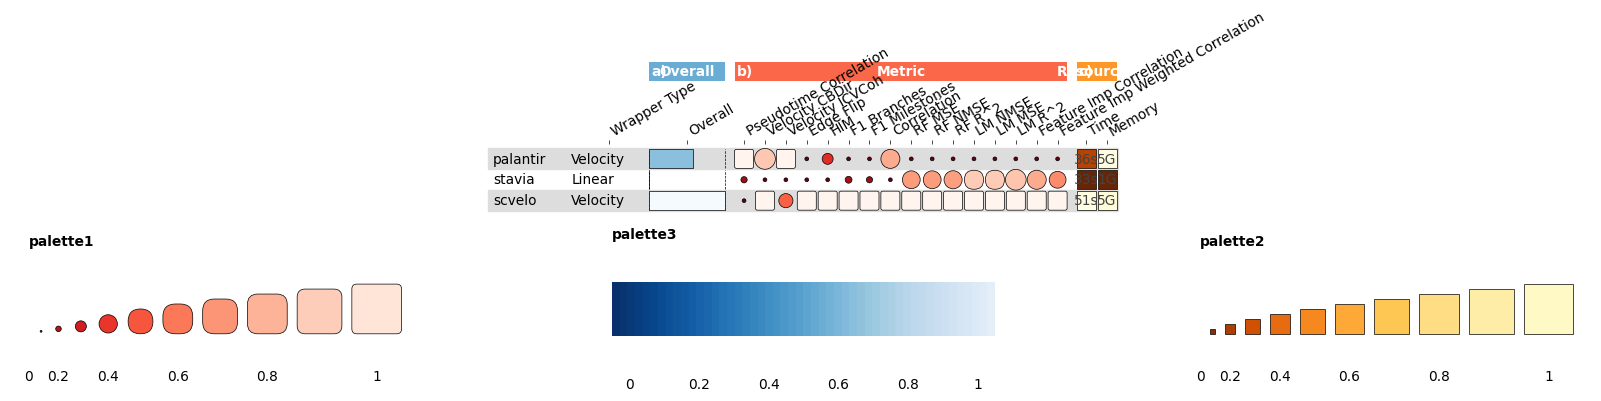

In [6]:
import matplotlib.pyplot as plt
import funkyheatmappy

plt.figure(figsize=(32, 24))

# 样式参考dynbenchmark: https://funkyheatmap.github.io/funkyheatmap/articles/dynbenchmark.html
column_list = [
    ["id", "group", "name", "geom", "options", "palette"],
    ["id", np.nan, "", "text", {"ha": 0, "width": 4}, np.nan],
    ["type", np.nan, "Wrapper Type", "text", {"ha": 0, "width": 4}, np.nan],
    ["overall", "overall", "Overall", "bar", {"width": 4, "legend": False}, "palette3"],
    # metric group, added by latter 'id2name' dict
    # resource group
    ["time", "group2", "Time", "rect", "scaling", "palette2"],
    ["time_text", "group2", "", "text", {"overlay": True, "size": 3, "scale": False}, "white6black4"],  # add time value text
    ["memory", "group2", "Memory", "rect", "scaling", "palette2"],
    ["memory_text", "group2", "", "text", {"overlay": True, "size": 3, "scale": False}, "white6black4"],  # add memory value text

]

id2name = {
    "pseudotime_correlation": "Pseudotime Correlation",
    "velocity_cbdir": "Velocity CBDir",
    "velocity_icvcoh": "Velocity ICVCoh",
    "edge_flip": "Edge Flip",
    "him": "HIM",
    # "isomorphic": "Isomorphic",
    "F1_branches": "F1 Branches",
    "F1_milestones": "F1 Milestones",
    "correlation": "Correlation",
    "rf_mse": "RF MSE",
    "rf_nmse": "RF NMSE",
    "rf_rsq": "RF R^2",
    "lm_nmse": "LM NMSE",
    "lm_mse": "LM MSE",
    "lm_rsq": "LM R^2",
    "featureimp_cor": "Feature Imp Correlation",
    "featureimp_wcor": "Feature Imp Weighted Correlation",
}

metric_column_list = []
for id, name in id2name.items():
    metric_column_list.append([id, "group1", name, "funkyrect", "options", "palette1"])
column_list = column_list[:4] + metric_column_list + column_list[4:]

column_info = pd.DataFrame(column_list[1:], columns=column_list[0])
column_info.index = column_info["id"]

column_groups = pd.DataFrame(
    columns=["Category", "group", "palette"],
    data=[["Overall", "overall", "palette3"],
          ["Metric", "group1", "palette1"],
          ["Resources", "group2", "palette2"]]
)

funkyheatmappy.funky_heatmap(benchmark_df, column_info=column_info, column_groups=column_groups)

plt.savefig("benchmark_heatmap.pdf", dpi=300)
plt.show()